In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 211k/211k [00:01<00:00, 210kB/s]


Extracting model files...
Path to dataset files: C:\Users\Administrator\.cache\kagglehub\datasets\uciml\sms-spam-collection-dataset\versions\1


In [223]:
import pandas as pd
import numpy as np
import string
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [112]:
!pip install wordcloud

In [41]:
df = pd.read_csv(r'C:\Users\Administrator\Dataset\sms-spam-collection-dataset\spam.csv', encoding='latin-1')

In [42]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [44]:
df.isna().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [45]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [46]:
df.duplicated().sum()

403

In [47]:
df.drop_duplicates(inplace=True)

In [49]:
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)

In [50]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [54]:
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [55]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 1. EDA

In [57]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

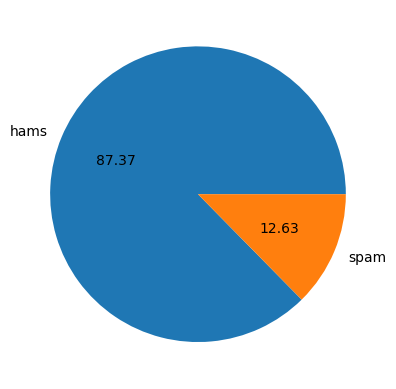

In [61]:
plt.pie(df['target'].value_counts(), labels=['hams', 'spam'], autopct='%0.2f')
plt.show()

    The data is not perfectly balanced, as we could see hams has almost 87% of data while spams are just 12%

In [64]:
df[df['target']==1]

,target,text
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
5,1,FreeMsg Hey there darling it's been 3 week's n...
8,1,WINNER!! As a valued network customer you have...
9,1,Had your mobile 11 months or more? U R entitle...
11,1,"SIX chances to win CASH! From 100 to 20,000 po..."
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


In [66]:
df['num_words'] = df['text'].apply(len)

In [67]:
df

,target,text,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161
5568,0,Will Ì_ b going to esplanade fr home?,37
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [71]:
df[df['target']==0].describe()

,target,num_words
count,4516.0,4516.000000
mean,0.0,70.459256
std,0.0,56.358207
min,0.0,2.000000
25%,0.0,34.000000
50%,0.0,52.000000
75%,0.0,90.000000
max,0.0,910.000000


In [72]:
df[df['target']==1].describe()

,target,num_words
count,653.0,653.000000
mean,1.0,137.891271
std,0.0,30.137753
min,1.0,13.000000
25%,1.0,132.000000
50%,1.0,149.000000
75%,1.0,157.000000
max,1.0,224.000000


<Axes: xlabel='num_words', ylabel='Count'>

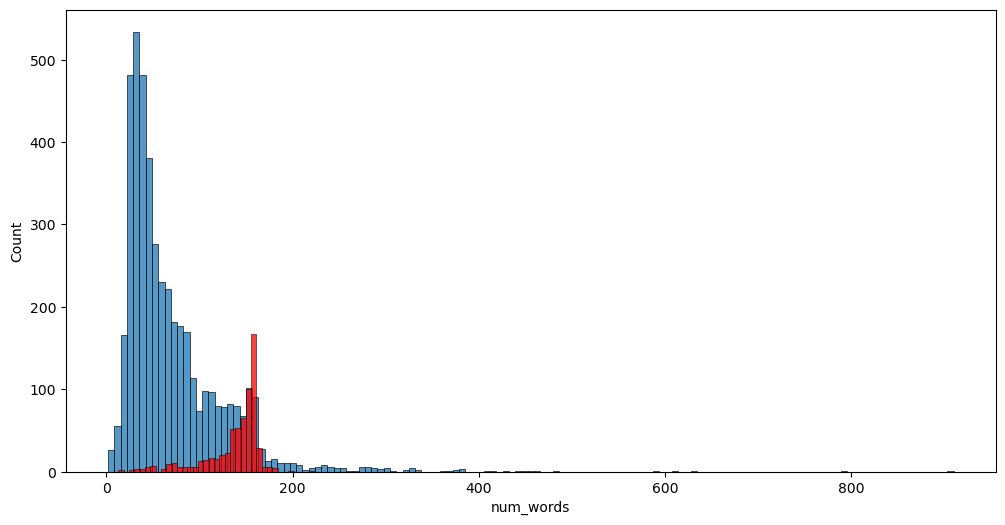

In [73]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

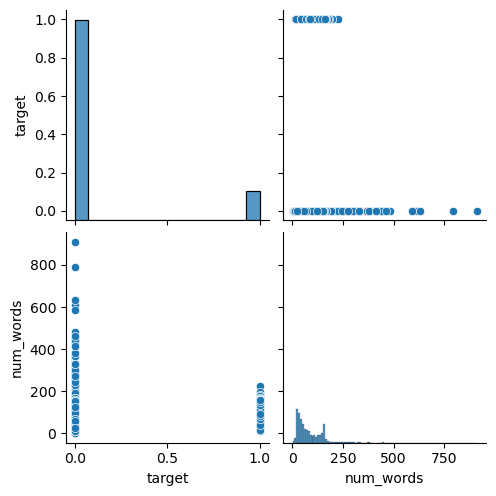

In [74]:
sns.pairplot(df)

## 2. Data Preprocessing
    Lower case
    Tokenization
    Removing special characters
    Removing stop words and punctuation
    Stemming

In [86]:
ps = PorterStemmer()

In [149]:
def preprocessing(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)

In [150]:
preprocessing("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [145]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [157]:
df['transformed_text'] = df['text'].apply(preprocessing)

In [158]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [159]:
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

In [161]:
ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

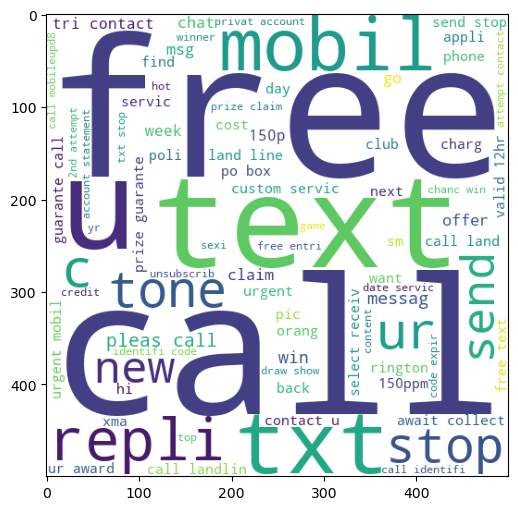

In [160]:
plt.figure(figsize=(12, 6))
plt.imshow(spam_wc)

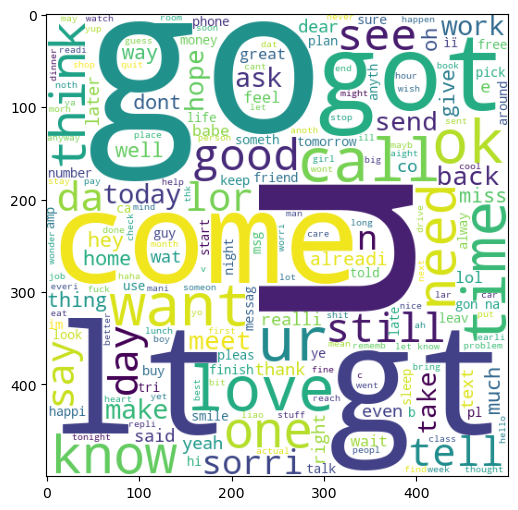

In [162]:
plt.figure(figsize=(12, 6))
plt.imshow(ham_wc)

In [163]:
spam_corpus = []
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [164]:
ham_corpus = []
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [125]:
pd.DataFrame(Counter(spam_corpus).most_common(30))[1]

0     640
1     595
2     382
3     330
4     310
5     282
6     267
7     252
8     244
9     238
10    238
11    228
12    208
13    206
14    196
15    194
16    183
17    183
18    164
19    164
20    157
21    148
22    144
23    128
24    128
25    126
26    122
27    121
28    120
29    116
Name: 1, dtype: int64

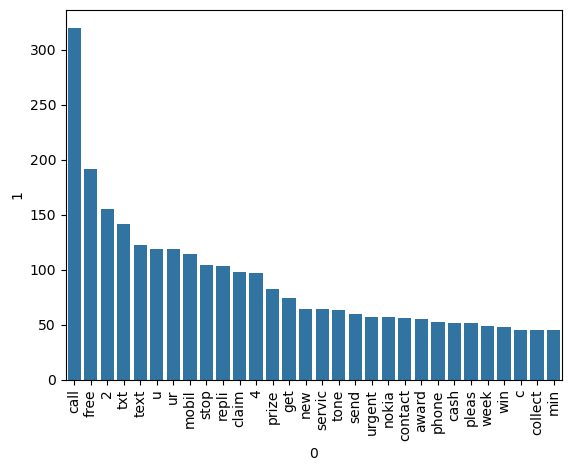

In [165]:
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0], y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

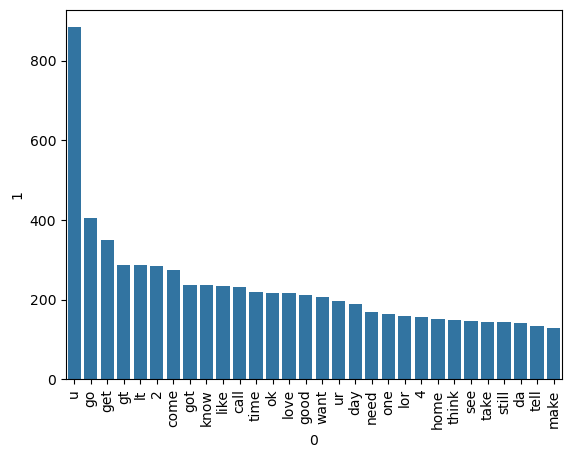

In [166]:
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0], y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [167]:
len(ham_corpus)

35404

In [168]:
len(spam_corpus)

9939

In [148]:
ps.stem('keeping')

'keep'

## 3. Model Building

In [170]:
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [230]:
X_idf =  tfidf.fit_transform(df['transformed_text']).toarray()

In [231]:
X = np.hstack((X_idf, df['num_words'].values.reshape(-1, 1))) 

In [232]:
X.shape

(5169, 3001)

In [233]:
y = df['target'].values

In [174]:
y.shape

(5169,)

In [234]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [235]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [179]:
gnb.fit(X_train, y_train)
y_pred_1 = gnb.predict(X_test)
print('Accuracy is :',accuracy_score(y_test, y_pred_1))
print('Confusion Matrix :',confusion_matrix(y_test, y_pred_1))
print('precision is :',precision_score(y_test, y_pred_1))

Accuracy is : 0.8694390715667312
Confusion Matrix : [[788 108]
 [ 27 111]]
precision is : 0.5068493150684932


In [180]:
mnb.fit(X_train, y_train)
y_pred_2 = mnb.predict(X_test)
print('Accuracy is :',accuracy_score(y_test, y_pred_2))
print('Confusion Matrix :',confusion_matrix(y_test, y_pred_2))
print('precision is :',precision_score(y_test, y_pred_2))

Accuracy is : 0.9709864603481625
Confusion Matrix : [[896   0]
 [ 30 108]]
precision is : 1.0


In [236]:
mnb.fit(X_train, y_train)
y_pred_2 = mnb.predict(X_test)
print('Accuracy is :',accuracy_score(y_test, y_pred_2))
print('Confusion Matrix :',confusion_matrix(y_test, y_pred_2))
print('precision is :',precision_score(y_test, y_pred_2))

Accuracy is : 0.9410058027079303
Confusion Matrix : [[896   0]
 [ 61  77]]
precision is : 1.0


In [202]:
bnb.fit(X_train, y_train)
y_pred_3 = bnb.predict(X_test)
print('Accuracy is :',accuracy_score(y_test, y_pred_3))
print('Confusion Matrix :',confusion_matrix(y_test, y_pred_3))
print('precision is :',precision_score(y_test, y_pred_3))

Accuracy is : 0.9835589941972921
Confusion Matrix : [[895   1]
 [ 16 122]]
precision is : 0.991869918699187


In [183]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
from xgboost import XGBClassifier

In [185]:
lr = LogisticRegression()
dtc = DecisionTreeClassifier()
svc = SVC()
mn = MultinomialNB()
knc = KNeighborsClassifier()
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbc = GradientBoostingClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
xgc = XGBClassifier()

In [186]:
clfs = {
    'LogisticRegression' : lr,
    'DecisionTreeClassifier' : dtc,
    'SVC' : svc,
    'MultinomialNB' : mn,
    'KNeighborsClassifier' : knc,
    'BaggingClassifier' : bc,
    'ExtraTreesClassifier' : etc,
    'GradientBoostingClassifier' : gbc,
    'AdaBoostClassifier' : abc,
    'RandomForestClassifier' : rfc,
    'XGBClassifier' : xgc
}

In [203]:
def train_classifier(clf, X_train, X_test, y_train, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision

In [241]:
train_classifier(lr, X_train, X_test, y_train, y_test)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


(0.9671179883945842, 0.9905660377358491)

In [244]:
accuracy_list =[]
precision_list = []
for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, X_test, y_train, y_test)

    accuracy_list.append(current_accuracy)
    precision_list.append(current_precision)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [245]:
performance_df_nums = pd.DataFrame({
    'Algorithm' : clfs.keys(),
    'Accuracy_num' : accuracy_list,
    'Precision_num' : precision_list
})

In [246]:
performance_df_nums

,Algorithm,Accuracy_num,Precision_num
0,LogisticRegression,0.967118,0.990566
1,DecisionTreeClassifier,0.946809,0.812030
2,SVC,0.866538,0.000000
3,MultinomialNB,0.941006,1.000000
4,KNeighborsClassifier,0.926499,0.762712
5,BaggingClassifier,0.966151,0.899225
6,ExtraTreesClassifier,0.978723,0.975410
7,GradientBoostingClassifier,0.950677,0.930693
8,AdaBoostClassifier,0.946809,0.902913
9,RandomForestClassifier,0.969052,0.981818


In [247]:
performance_df_nums.merge(performance_df, on = "Algorithm")

,Algorithm,Accuracy_num,Precision_num,Accuracy,Precision
0,LogisticRegression,0.967118,0.990566,0.956480,0.979381
1,DecisionTreeClassifier,0.946809,0.812030,0.952611,0.815603
2,SVC,0.866538,0.000000,0.972921,0.982456
3,MultinomialNB,0.941006,1.000000,0.970986,1.000000
4,KNeighborsClassifier,0.926499,0.762712,0.905222,1.000000
5,BaggingClassifier,0.966151,0.899225,0.958414,0.868217
6,ExtraTreesClassifier,0.978723,0.975410,0.974855,0.974576
7,GradientBoostingClassifier,0.950677,0.930693,0.946809,0.919192
8,AdaBoostClassifier,0.946809,0.902913,0.924565,0.848837
9,RandomForestClassifier,0.969052,0.981818,0.975822,0.982906


In [238]:
performance_df1

,Algorithm,variable,value
0,LogisticRegression,Accuracy,0.956480
1,DecisionTreeClassifier,Accuracy,0.952611
2,SVC,Accuracy,0.972921
3,MultinomialNB,Accuracy,0.970986
4,KNeighborsClassifier,Accuracy,0.905222
5,BaggingClassifier,Accuracy,0.958414
6,ExtraTreesClassifier,Accuracy,0.974855
7,GradientBoostingClassifier,Accuracy,0.946809
8,AdaBoostClassifier,Accuracy,0.924565
9,RandomForestClassifier,Accuracy,0.975822


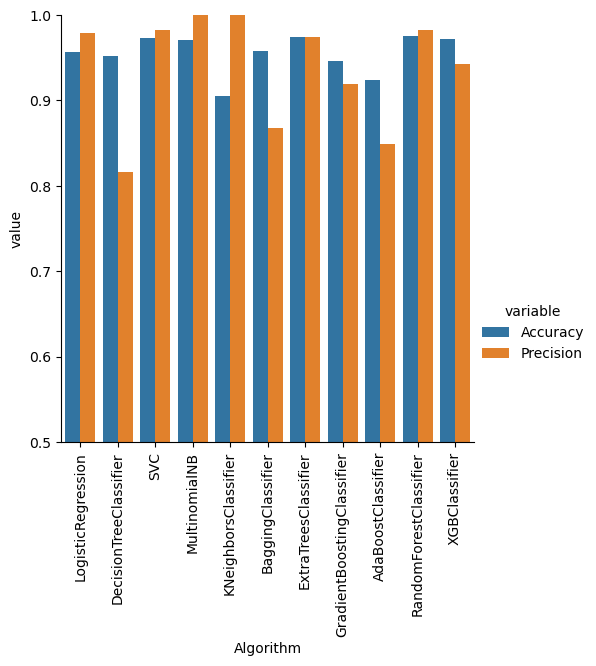

In [240]:
sns.catplot(
    x = 'Algorithm', 
    y='value', 
    hue = 'variable',
    data=performance_df1, 
    kind='bar',
    height=5
)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [248]:
from sklearn.ensemble import VotingClassifier

In [251]:
voting = VotingClassifier(estimators=[('mn1',mn),('mn2',mn),('mn3',mn)], voting='soft')

In [252]:
voting.fit(X_train, y_train)

VotingClassifier(estimators=[('mn1', MultinomialNB()), ('mn2', MultinomialNB()),
                             ('mn3', MultinomialNB())],
                 voting='soft')

In [253]:
y_pred_v = voting.predict(X_test)
print("Accuracy ",accuracy_score(y_test, y_pred_v))
print("Precision ",precision_score(y_test, y_pred_v))


Accuracy  0.9410058027079303
Precision  1.0


In [254]:
from sklearn.ensemble import StackingClassifier

In [266]:
estimators = [
    ('mn1', mn),
    ('mn2', mn),
]

In [273]:
stacking = StackingClassifier(
    estimators = estimators,
    final_estimator=KNeighborsClassifier(),
    cv = 3,
    n_jobs = -1,
    verbose = 1
)

In [274]:
stacking.fit(X_train, y_train)

StackingClassifier(cv=3,
                   estimators=[('mn1', MultinomialNB()),
                               ('mn2', MultinomialNB())],
                   final_estimator=KNeighborsClassifier(), n_jobs=-1,
                   verbose=1)

In [275]:
y_pred_s = stacking.predict(X_test)
print('accuracy ',accuracy_score(y_test, y_pred_s))
print('Precision ',precision_score(y_test, y_pred_s))

accuracy  0.9303675048355899
Precision  0.7037037037037037


## 